In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import pandas as pd
import joblib
from pathlib import Path

import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 16, 'font.family': 'serif'})

import warnings

warnings.filterwarnings("ignore")


In [10]:
# generate a table with features recap

task_dict = {
    'azure': '1. TSF',
    'WSD_3k': '1. TSF',
    'WSD': '2. TSAD',
    'AIOPS': '2. TSAD',
    'VMs': '3. SSD',
    'JMH': '3. SSD'
}

data = []

for path in Path("data/features").glob("selected_*.csv"):
    # dataset name is the first part of filename removing the last underscore and the extension
    dataset_name = path.stem.split("_", maxsplit=1)[1]
    df = pd.read_csv(path, index_col='id')
    # example features: y__abs_energy,"y__agg_linear_trend__attr_""rvalue""__chunk_len_10__f_agg_""max""",y__ar_coefficient__coeff_3__k_10,y__count_above_mean,"y__fft_aggregated__aggtype_""centroid""",
    features_categories = [re.sub(r"^y__", "", f).split("__")[0] for f in df.columns]
    unique_categories = set(features_categories)
    _details = {
        "dataset_name": dataset_name,
        "task": task_dict[dataset_name],
        "n_features": len(df.columns),
        "n_categories": len(unique_categories),
    }
    data.append(_details)
    
qualit_analysis_table = pd.DataFrame(data)

# beautify and export in latex format
qualit_analysis_table = qualit_analysis_table.sort_values(by=['task', 'dataset_name'])
qualit_analysis_table

qualit_analysis_table = qualit_analysis_table.set_index(['task', 'dataset_name'])[[
    "n_features",
    "n_categories"
]].T.sort_index(axis=1, level=[0,1])#.applymap(lambda x: '(-)' if pd.notnull(x) and abs(x) < 1 else x)

# establish an order for the tasks
task_order = ['TSF', 'TSAD', 'SSD']

qualit_analysis_table.to_latex("results/tex/selected_features.tex", column_format="l|cc|cc|cc", escape=True)

qualit_analysis_table

task         1. TSF       2. TSAD      3. SSD    
dataset_name WSD_3k azure   AIOPS  WSD    JMH VMs
n_features       20    39       9  112      8   5
n_categories      8    14       4   25      8   5

In [11]:
# load all joblibs random forests inside results/checkpoints folder

ckpt_path = Path("./results/checkpoints/")

loaded_models = {}

# read all files
for file in ckpt_path.glob("*.joblib"):
    dataset_name = file.stem.split("___")[0]
    fold_name = file.stem.split("___")[1]

    model = joblib.load(file)
    loaded_models[(dataset_name, fold_name)] = model

In [12]:
import numpy as np
import pandas as pd
from collections import defaultdict

# Extract feature importances with feature names per fold
feature_importances_dict = {}
for (dataset_name, fold_name), model in loaded_models.items():
    feature_importances_dict[(dataset_name, fold_name)] = {
        feature: importance
        for feature, importance in zip(model.feature_names_in_, model.feature_importances_)
    }

# Collect all unique features per dataset
dataset_features = defaultdict(set)
for (dataset_name, fold_name) in feature_importances_dict:
    dataset_features[dataset_name].update(feature_importances_dict[(dataset_name, fold_name)].keys())

# Build per-fold DataFrames per dataset, filling missing features with NaN
fold_importance_dfs = {}
for dataset_name, all_features in dataset_features.items():
    fold_records = []
    fold_index = []
    for (ds_name, fold_name), feat_importance_map in feature_importances_dict.items():
        if ds_name != dataset_name:
            continue
        # Fill missing features with NaN instead of 0
        fold_vector = {feature: feat_importance_map.get(feature, np.nan) for feature in all_features}
        fold_records.append(fold_vector)
        fold_index.append(fold_name)

    fold_df = pd.DataFrame(fold_records, index=fold_index, columns=sorted(all_features))
    fold_df.index.name = "fold"
    fold_importance_dfs[dataset_name] = fold_df.sort_index()

In [13]:
summarized_mapping = {
    "AzFuncInvoke": {
        'y__longest_strike_below_mean': 'Long. Strike\nBelow Mean', 
        'y__augmented_dickey_fuller__attr_"teststat"__autolag_"AIC"': 'ADF Test Statistic\n(AIC Lag)', 
        'y__augmented_dickey_fuller__attr_"pvalue"__autolag_"AIC"': 'ADF P-Value\n(AIC Lag)', 
        'y__agg_autocorrelation__f_agg_"var"__maxlag_40': 'Agg. Autocorr.\nVar, Max Lag 40', 
        'y__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)': 'CWT\nc=0,w=10,...'
    },
    "WSD_3k": {
        'y__energy_ratio_by_chunks__num_segments_10__segment_focus_4': 'Energy Ratio\ns=10,f=4', 
        'y__fft_coefficient__attr_"imag"__coeff_75': 'FFT Coef.\n(Imag, c=75)', 
        'y__fft_coefficient__attr_"real"__coeff_12': 'FFT Coef.\n(Real, c=12)', 
        'y__fft_coefficient__attr_"angle"__coeff_66': 'FFT Coef.\n(Angle, c=66)', 
        'y__longest_strike_below_mean': 'Long. Strike\nBelow Mean'
    },
    "WSD": {
        'y__ar_coefficient__coeff_3__k_10': 'AR Coef.\n(c=3, k=10)', 
        'y__ratio_beyond_r_sigma__r_3': 'Ratio Beyond\nR Sigma (r=3)', 
        'y__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)': 'CWT\nc=0,w=10,...', 
        'y__fft_coefficient__attr_"real"__coeff_38': 'FFT Coef.\n(Real, c=38)', 
        'y__ar_coefficient__coeff_10__k_10': 'AR Coef.\n(c=10, k=10)'
    },
    "AIOps": {
        'y__fft_coefficient__attr_"angle"__coeff_26': 'FFT Coef.\n(Angle, c=26)', 
        'y__ar_coefficient__coeff_1__k_10': 'AR Coef.\n(c=1, k=10)', 
        'y__agg_autocorrelation__f_agg_"var"__maxlag_40': 'Agg. Autocorr.\nVar, Max Lag 40', 
        'y__fft_coefficient__attr_"angle"__coeff_50': 'FFT Coef.\n(Angle, c=50)', 
        'y__longest_strike_above_mean': 'Long. Strike\nAbove Mean'
    },
    "VMs": {
        'y__absolute_sum_of_changes': 'Abs. Sum\nof Changes', 
        'y__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)': 'CWT\nc=0,w=2,...', 
        'y__abs_energy': 'Abs. Energy', 
        'y__absolute_maximum': 'Abs. Maximum', 
        'y__ar_coefficient__coeff_8__k_10': 'AR Coef.\n(c=8, k=10)'
    },
    "jmh": {
        'y__index_mass_quantile__q_0.1': 'Index Mass Quantile\n(q=0.1)', 
        'y__ratio_beyond_r_sigma__r_1.5': 'Ratio Beyond\nR Sigma (r=1.5)', 
        'y__fft_aggregated__aggtype_"centroid"': 'FFT Aggregated\n(Centroid)', 
        'y__abs_energy': 'Abs. Energy', 
        'y__agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"max"': 'Agg. Linear Trend\n(R-Value, Max)'
    }
}

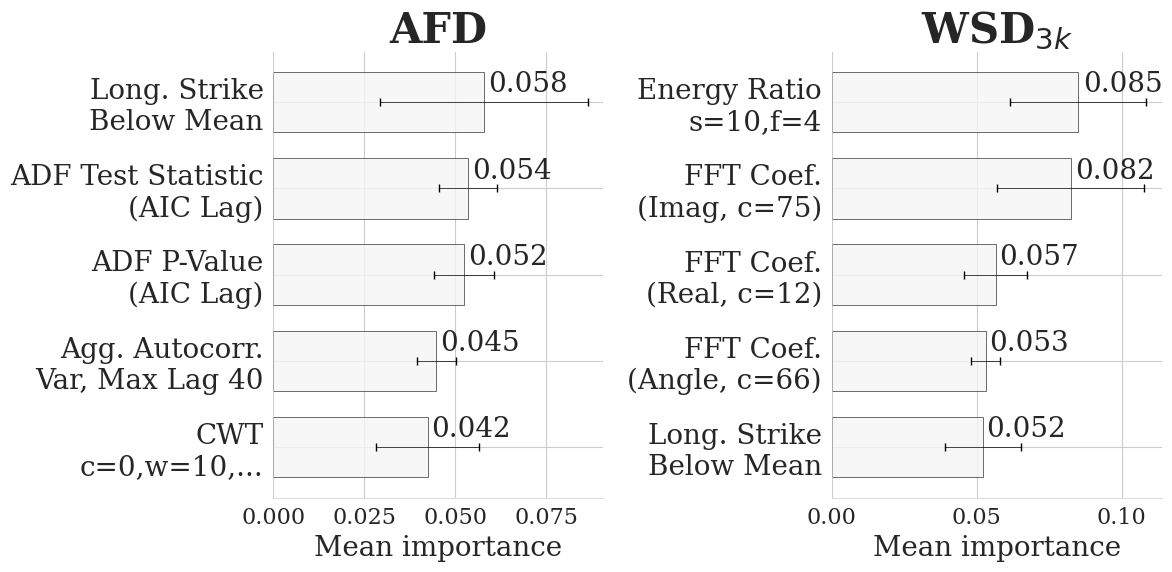

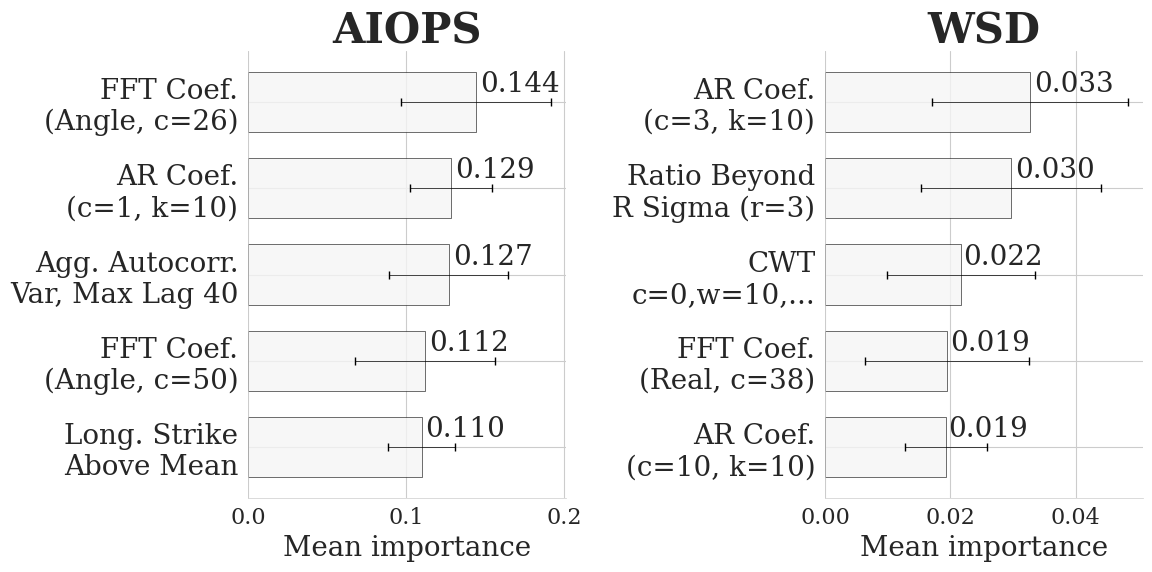

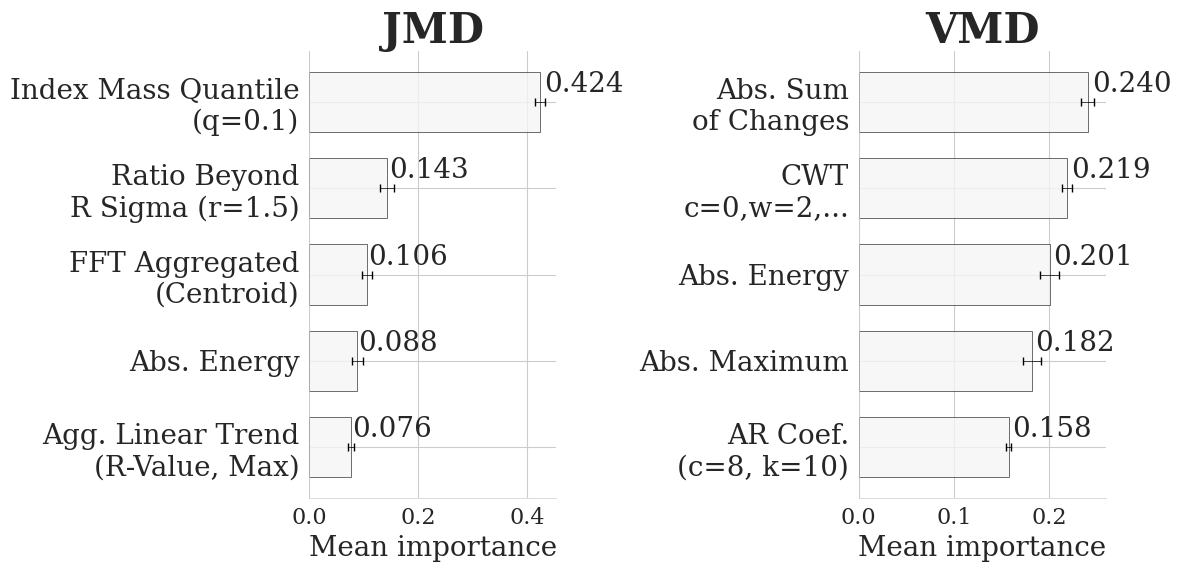

In [14]:
task_dict = {
    'AzFuncInvoke': 'TSF',
    'WSD_3k': 'TSF',
    'WSD': 'TSAD',
    'AIOps': 'TSAD',
    'VMs': 'SSD',
    'jmh': 'SSD'
}

datasets_labels = {
    'AzFuncInvoke': 'AFD',
    'WSD_3k': 'WSD$_{3k}$',
    'WSD': 'WSD',
    'AIOps': 'AIOPS',
    'VMs': 'VMD',
    'jmh': 'JMD'
}

# ── 1. Aggregate across folds ────────────────────────────────────────────
agg = {}
for name, df in fold_importance_dfs.items():
    agg[name] = pd.DataFrame({
        "mean": df.mean(axis=0),
        "std":  df.std(axis=0),
    }).sort_values("mean", ascending=False)

top_k = 5

# ── Palette: one color per task ──────────────────────────────────────────────
TASK_COLORS = {
    task: color for task, color in zip(
        sorted(set(task_dict.values())),
        ["#4A90D9", "#E8724A", "#5BAD8F"]   # blue / coral / teal
    )
}

# Known long term → short label mappings
_TERM_MAP = {
    "agg_autocorrelation":    "autocorr",
    "ar_coefficient":         "AR coef",
    "fft_coefficient":        "FFT coef",
    "augmented_dickey_fuller":"ADF",
    "energy_ratio_by_chunks": "energy ratio",
    "f_agg":                  "",           # absorbed into value
    "autolag":                "lag",
    "maxlag":                 "lag",
    "coeff":                  "c",
    "coef":                   "c",
    "attr":                   "",           # absorbed into value
    "teststat":               "stat",
    "pvalue":                 "p-val",
    "mean":                   "μ",
    "var":                    "σ²",
    "median":                 "med",
    "cwt_coefficients":         "CWT coef",
}

def beautify_feature_name(name: str) -> str:
    name = re.sub(r'^y__', '', name)              # remove leading y__
    name = re.sub(r'"(\w+)"', r'\1', name)        # remove quotes

    parts = name.split('__')

    lines = []
    i = 0

    while i < len(parts):
        part = parts[i]
        mapped = _TERM_MAP.get(part)

        if mapped is None:
            lines.append(re.sub(r'_', ' ', part))
            i += 1

        elif mapped == "":
            # absorb key, preserve following value
            if i + 1 < len(parts):
                lines.append(str(_TERM_MAP.get(parts[i + 1], parts[i + 1])))
                i += 2
            else:
                i += 1

        else:
            # merge parameter values (e.g., maxlag__40 → lag 40)
            if i + 1 < len(parts) and parts[i + 1].isdigit():
                # lines.append(f"{mapped}={parts[i + 1]}")
                lines.append(f"{parts[i + 1]}")
                i += 2
            else:
                lines.append(mapped)
                i += 1

    # Keep feature hierarchy readable:
    # first element = feature name, remaining elements = parameters
    if len(lines) > 2:
        formatted = [lines[0], ", ".join(lines[1:])]
    else:
        formatted = lines

    return "\n".join(formatted).strip().title()

dataset_dict = {
    "AFD": "AFD",
    "WSD$_{3k}$": "WSD$_{3k}$",
    "WSD": "WSD",
    "AIOPS": "AIOPS",
    "VMD": "VMD",
    "JMD": "JMD"
}

def plot_importance_by_task(agg, task_dict, task_order, top_k=10):
    for task in task_order:
        task_datasets = [n for n in agg if task_dict[n] == task]
        color = "whitesmoke" # TASK_COLORS[task]
        n_cols = len(task_datasets)
        
        fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 6), facecolor="white")
        if n_cols == 1:
            axes = [axes]
        
        for ax, name in zip(axes, task_datasets):
            df = agg[name].copy()
            # print(name, {feat: "<summary>" for feat in df.head(top_k).index})
            df.index = [summarized_mapping[name].get(f, f) for f in df.index]
            top = df.head(top_k)
            
            # Minimal barplot
            bars = ax.barh(
                top.index, top["mean"],
                xerr=top["std"],
                color=color, alpha=0.8,
                capsize=3, error_kw={"elinewidth": 0.5, "ecolor": "black"},
                height=0.7, edgecolor="black", linewidth=0.5
            )
            
            # Simple value labels
            for bar, val in zip(bars, top["mean"]):
                ax.text(val * 1.02, bar.get_y() + bar.get_height() / 2 - 0.2,
                        f"{val:.3f}", va="center", ha="left", fontsize=20)
            
            ax.invert_yaxis()
            ax.set_title(dataset_dict[datasets_labels.get(name, name)], fontsize=30, fontweight="bold")
            ax.set_xlabel("Mean importance", fontsize=20)
            ax.tick_params(axis="y", labelsize=20)
            ax.tick_params(axis="x", labelsize=16)
            ax.spines[["top", "right"]].set_visible(False)
            ax.spines[["left", "bottom"]].set_linewidth(0.5)
        
        # fig.suptitle(
        #     f"Task: {task}  —  Top {top_k} features",
        #     fontsize=16, fontweight="bold", y=1.00
        # )
        plt.tight_layout()
        # plt.savefig(f"results/features/feature_importance_{task}.pdf", dpi=300, bbox_inches='tight')
        plt.show()

plot_importance_by_task(agg, task_dict, task_order=['TSF', 'TSAD', 'SSD'], top_k=5)

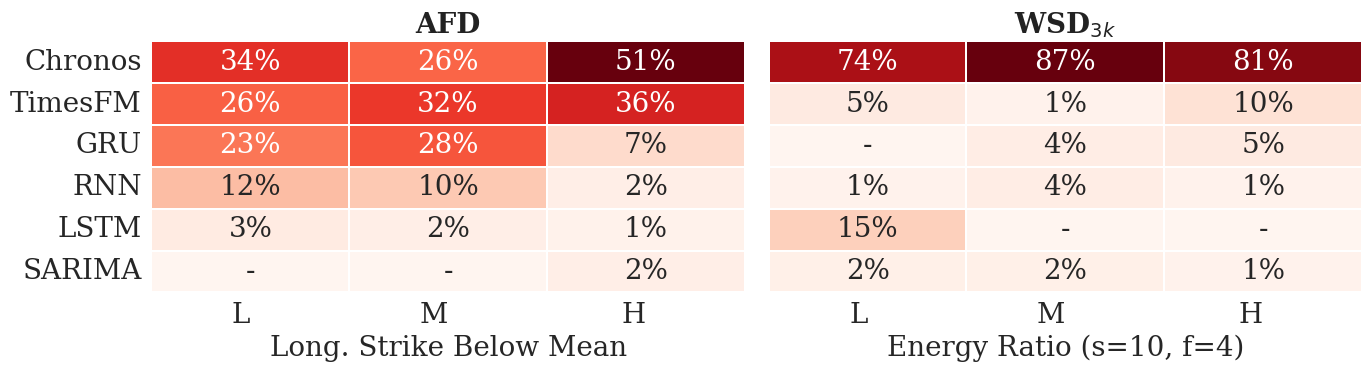

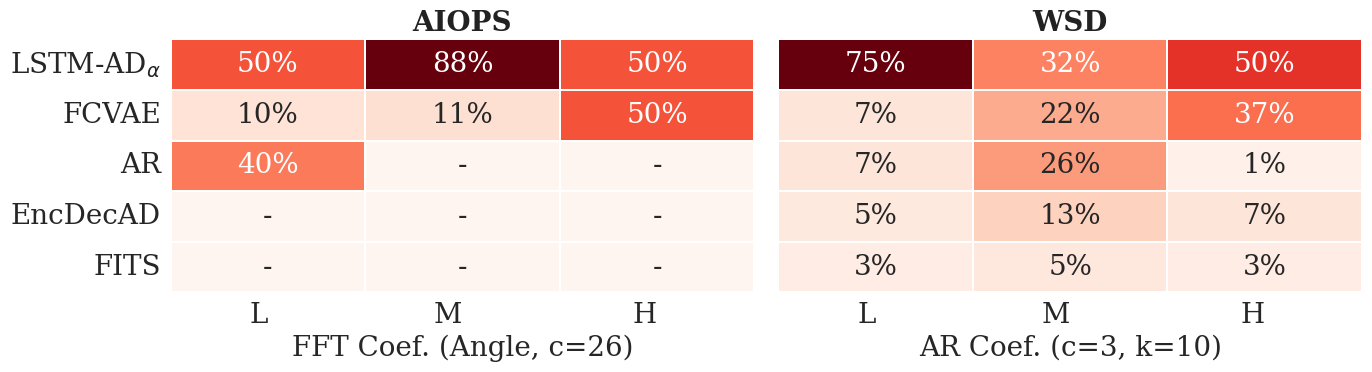

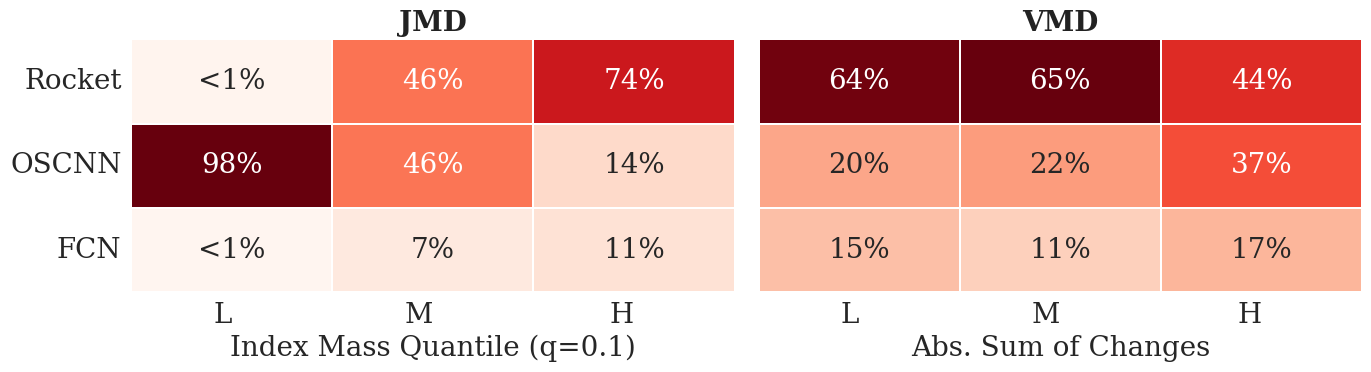

In [15]:
import seaborn as sns

# heatmaps
task_order=['TSF', 'TSAD', 'SSD']

filenames_dataset = {
    'AzFuncInvoke': 'azure',
    'WSD_3k': 'WSD_3k',
    'WSD': 'WSD',
    'AIOps': 'AIOPS',
    'VMs': 'VMs',
    'jmh': 'JMH',
}

dataset_dict = {
    "AzFuncInvoke": "AFD",
    "WSD_3k": "WSD$_{3k}$",
    "WSD": "WSD",
    "AIOps": "AIOPS",
    "VMs": "VMD",
    "jmh": "JMD"
}

renamed_models = {
    "LSTMADalpha": "LSTM-AD$_{\\alpha}$",
    "RNN_RNN": "RNN",
    "RNN_LSTM": "LSTM",
    "RNN_GRU": "GRU",
}

features_dict = {
    'y__longest_strike_below_mean': "Long. Strike Below Mean",
    'y__energy_ratio_by_chunks__num_segments_10__segment_focus_4': "Energy Ratio (s=10, f=4)",
    'y__ar_coefficient__coeff_3__k_10': "AR Coef. (c=3, k=10)",
    'y__fft_coefficient__attr_"angle"__coeff_26': "FFT Coef. (Angle, c=26)",
    'y__absolute_sum_of_changes': "Abs. Sum of Changes",
    'y__index_mass_quantile__q_0.1': "Index Mass Quantile (q=0.1)",
}

all_models = {
    "TSF": ["Chronos", "TimesFM", "RNN_GRU", "RNN_RNN", "RNN_LSTM", "SARIMA"],
    "TSAD": ["LSTMADalpha", "FCVAE", "AR", "EncDecAD", "FITS"],
    "SSD": ["Rocket", "OSCNN", "FCN"]
}

for task in task_order:
    task_datasets = [n for n in agg if task_dict[n] == task]
    color = TASK_COLORS[task]
    n_cols = len(task_datasets)

    fig, axes = plt.subplots(
        1, n_cols,
        figsize=(7 * n_cols, 4),
        facecolor="white",
        # sharey=True
    )

    if n_cols == 1:
        axes = [axes]

    for idx, (ax, name) in enumerate(zip(axes, task_datasets)):
        # print(f"Processing dataset '{name}' for task '{task}'")
        predictions = pd.read_csv(f"results/pred/meta_{name}.csv", index_col=0)
        features = pd.read_csv(f"data/features/selected_{filenames_dataset[name]}.csv", index_col=0)

        merged_df = predictions.join(features, how='inner')

        top_feature_by_importance = agg[name].head(1).index[0]
        # print(f"Top feature by importance for dataset '{name}': {top_feature_by_importance}")

        df = merged_df[[top_feature_by_importance, 'model']].copy()

        bin_edges = pd.qcut(
            df[top_feature_by_importance],
            q=3,
            retbins=True
        )[1]

        # print(f"Bin edges for dataset '{name}': {bin_edges}")

        bin_labels = ["L", "M", "H"]

        df["binned_feature"] = pd.cut(
            df[top_feature_by_importance],
            bins=bin_edges,
            labels=bin_labels,
            include_lowest=True
        )

        counts = (
            df.groupby(["model", "binned_feature"], observed=True)
            .size()
            .unstack(fill_value=0)
        )

        counts = (
            counts
            .reindex(index=all_models[task], fill_value=0)
            .reindex(columns=bin_labels, fill_value=0)
        )

        # print(counts)

        # Compute percentages
        percentages = counts.div(counts.sum(axis=0), axis=1).fillna(0) * 100

        # percentages = counts.div(counts.sum(axis=0), axis=1) * 100

        annot = percentages.copy().astype(object)

        for row in percentages.index:
            for col in percentages.columns:
                val = percentages.loc[row, col]
                if val == 0:
                    annot.loc[row, col] = "-"
                elif val < 1:
                    annot.loc[row, col] = "<1%"
                else:
                    annot.loc[row, col] = f"{int(val)}%"

        sns.heatmap(
            percentages,
            ax=ax,
            cmap="Reds",
            vmin=0,
            vmax=percentages.to_numpy().max(),
            annot=annot,
            fmt="",
            annot_kws={"size": 20},
            linewidths=0.3,
            linecolor="white",
            cbar=False,
        )

        ax.set_xlabel(
            # f"Top Feature (binned dist.)\n{features_dict.get(top_feature_by_importance, top_feature_by_importance)}",
            features_dict.get(top_feature_by_importance, top_feature_by_importance),
            fontsize=20,
        )

        ax.set_title(
            f"{dataset_dict[name]}",
            fontsize=20,
            fontweight="bold",
            color="#222"
        )

        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=0,
            ha="right",
            fontsize=20
        )

        # Keep y labels only on the first subplot
        if idx == 0:
            # print("labels", [
            #         renamed_models.get(label.get_text(), label.get_text())
            #         for label in ax.get_yticklabels()
            # ])
            ax.set_ylabel("")
            ax.set_yticklabels(
                [
                    renamed_models.get(label.get_text(), label.get_text())
                    for label in ax.get_yticklabels()
                ],
                rotation=0,
                fontsize=20
            )
        else:
            ax.set_ylabel("")
            ax.tick_params(
                axis="y",
                left=False,
                labelleft=False
            )
    plt.tight_layout()
    # plt.savefig(f"results/features/selection_rate_{task}.pdf", dpi=300, bbox_inches='tight')
    # plt.savefig(f"results/features/selection_rate_{task}.png", dpi=300, bbox_inches='tight')
    plt.show()
        # break
    # break